# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# TODO: [Completa aquí] ¿Qué debes hacer con esta variable email?
email = '202643002@alu.comillas.edu'  # ⚠️ CAMBIAR POR TU EMAIL DE DATABRICKS

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    # TODO: [Completa aquí] ¿Para qué sirve set_tracking_uri?
    # Establece el servidor de MLflow para guardar automáticamente las métricas y modelos.
    mlflow.set_tracking_uri("databricks")
    
    # TODO: [Completa aquí] ¿Qué hace set_experiment?
    # Crea experimento en MLflow para organizar y agrupar todas las ejecuciones de entrenamiento del proyecto.
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

2026/10/02 17:21:41 INFO mlflow.tracking.fluent: Experiment with name '/Users/202643002@alu.comillas.edu/5-prediccion-infarto' does not exist. Creating a new experiment.


✅ MLflow configurado correctamente
📊 Experimento: /Users/202643002@alu.comillas.edu/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [0]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: [Completa aquí] ¿Para qué sirve train_test_split?
# Sirve para dividir los datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo en datos no vistos.
from sklearn.model_selection import train_test_split

# TODO: [Completa aquí] ¿Qué es un Pipeline en sklearn?
# Es una secuencia organizada de pasos que permite recrear la transformación de datos y la creación del modelo.
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# TODO: [Completa aquí] ¿Qué modelos vamos a usar?
# SGDClassifier y RandomForestClassifier para comparar su rendimiento y escoger cuál se adapta mejor a los datos.
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# TODO: [Completa aquí] ¿Para qué sirve cross_val_score?
# Realiza validación cruzada para evaluar la capacidad de generalización del modelo dividiendo los datos en varios folds.
from sklearn.model_selection import cross_val_score, cross_val_predict

# TODO: [Completa aquí] ¿Qué métricas usaremos y por qué?
# precisión, recall, F1-score, exactitud y ROC-AUC para evaluar los aciertos y falsos negativos en los resultados del modelo.
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [0]:
# TODO: Carga los datos y explica qué contiene el archivo.
# data = pd.read_csv(...)

# TODO: Muestra número de filas, columnas y variable objetivo.

# El dataset tiene los registros clínicos y variables de salud de los pacientes.
data = pd.read_csv("/Workspace/Users/202643002@alu.comillas.edu/clase_mlops_mlflow_202643002/data/raw/heart.csv") 

print(f"Número de filas (pacientes): {data.shape[0]}")
print(f"Número de columnas (características): {data.shape[1]}")
print("\nDistribución de la variable objetivo:")
print(data['target'].value_counts()) 


Número de filas (pacientes): 303
Número de columnas (características): 14

Distribución de la variable objetivo:
target
1    165
0    138
Name: count, dtype: int64


In [0]:
# TODO: Muestra las primeras filas con head().
# TODO: Explica por qué esta inspección es útil antes de modelar.

# data.head()

# Esta inspección permite verificar la correcta lectura del archivo y poder echar un primer vistazo a los datos.
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [0]:
# TODO: Usa info() para revisar tipos de datos y valores nulos.
# data.info()

# TODO: Anota qué columnas parecen categóricas y cuáles numéricas.

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 31.2+ KB


Las variables numéricas son age, trestbps, chol, thalach, oldpeak y thal. El target también pero realmente es un booleano.

Las categóricas son sex, cp, fbs, restecg, exang, slope, ca.

In [0]:
# TODO: Usa describe() para obtener estadísticas descriptivas.
# data.describe()

# TODO: Escribe observaciones sobre rangos, medias y posibles valores atípicos.

data.describe()


,age,trestbps,chol,thalach,oldpeak,ca,thal,target
count,303.000000,258.000000,273.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.465116,245.871795,149.646865,1.039604,0.729373,2.313531,0.544554
std,9.082101,16.914317,52.528792,22.905161,1.161075,1.022606,0.612277,0.498835
min,29.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,209.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,3.000000,1.000000


Se observan valores nulos en trestbps y chol

Una media de edad de 54 años (al tratarse de infartos tiene sentido que la edad sea tan elevada como media).

Un posible valor atípico puede ser el colesterol máximo (564 mg/dl).

### 💡 Observaciones Clave

**TODO: [Completa aquí] Basándote en las estadísticas, ¿qué observaciones puedes hacer sobre:**
- La edad media de los pacientes
- El rango de valores de cada característica
- La presencia de valores nulos
- Características que pueden necesitar normalización

In [0]:
# TODO: Analiza la distribución de la variable objetivo.
# target_counts = data.target.value_counts()
# print(target_counts)

# TODO: Calcula proporciones por clase.
# TODO: Decide si el dataset está balanceado y explica por qué importa.

target_counts = data['target'].value_counts()
print(target_counts)

print("\nProporciones por clase:")
print(data['target'].value_counts(normalize=True) * 100)


target
1    165
0    138
Name: count, dtype: int64

Proporciones por clase:
target
1    54.455446
0    45.544554
Name: proportion, dtype: float64


El dataset está bien balanceado (54.5% con enfermedad vs 45.5% sin enfermedad), esto evita que el modelo pueda hacer predicciones imbalanceadas. Por ejemplo si el 90% tienen enfermedad, un modelo que siempre categorice que la persona tiene enfermedad tendrá un 90% de acierto en test sin tener en cuenta ningúna variable.

### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

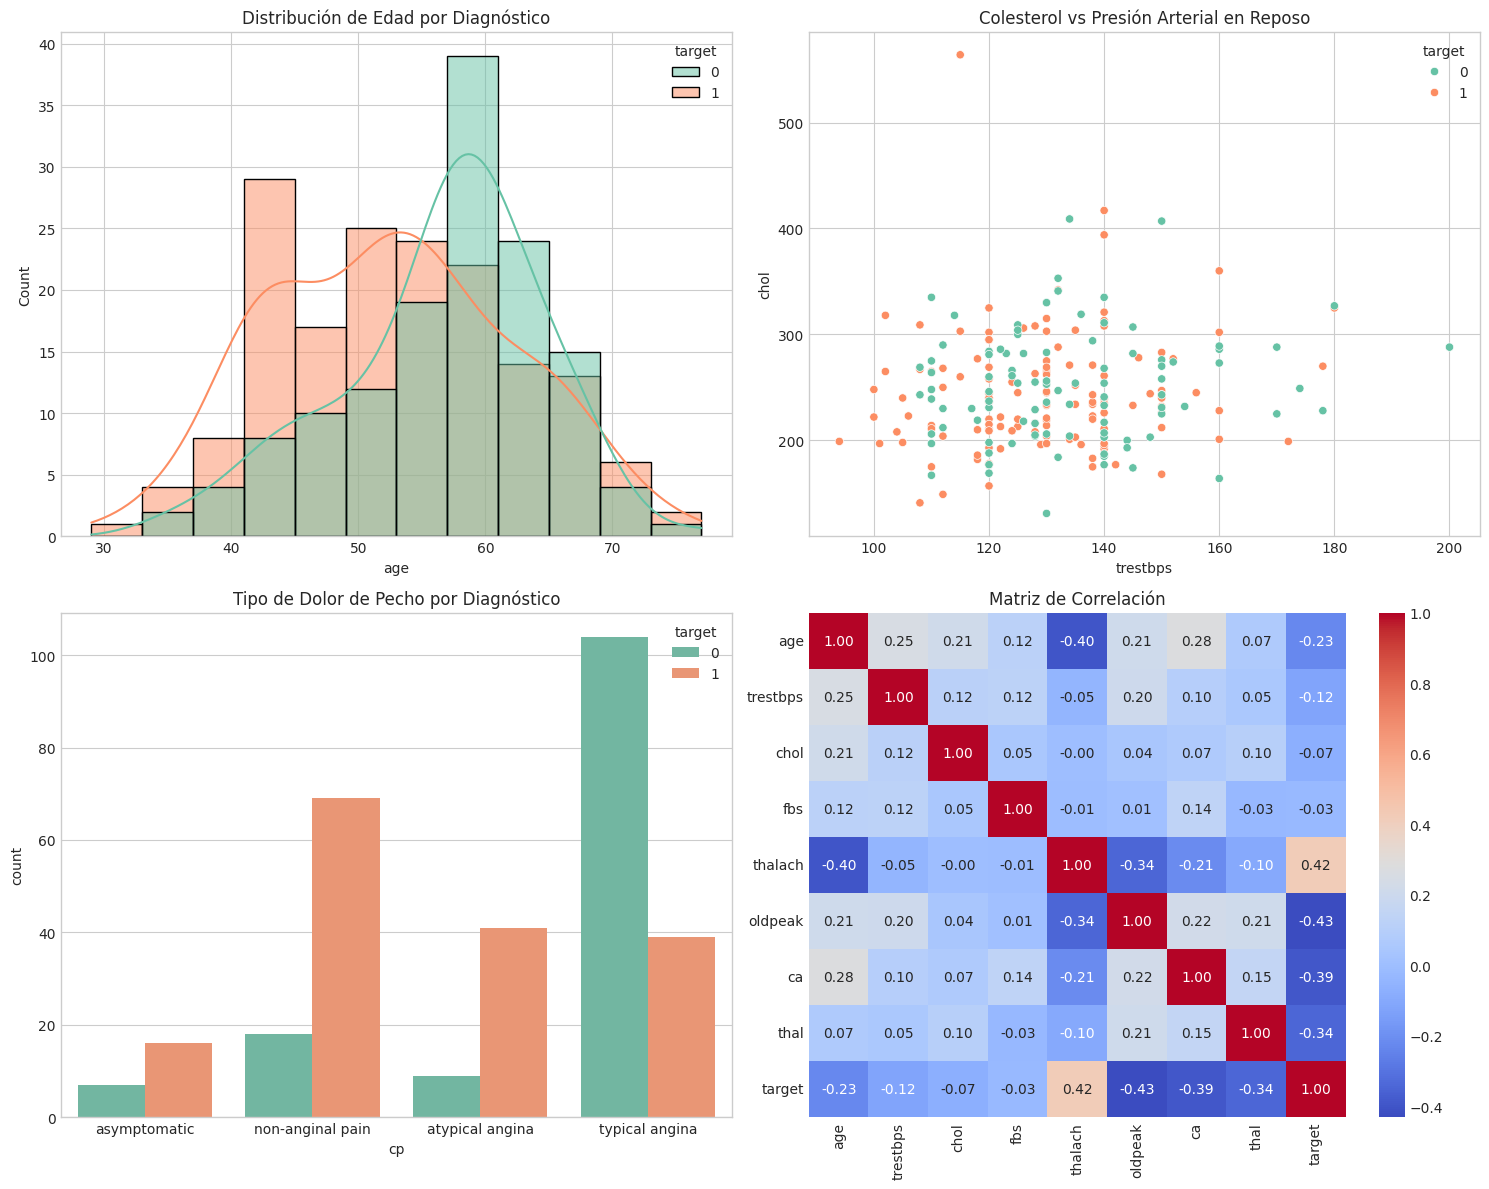

In [0]:
# TODO: Crea visualizaciones para explorar patrones del dataset.
# Ideas:
# - Distribución de edad por diagnóstico
# - Colesterol vs presión arterial coloreado por target
# - Tipo de dolor de pecho vs diagnóstico
# - Matriz de correlación

# fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# ...
# plt.show()

# TODO: Escribe qué patrones observas en los gráficos.

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(data=data, x='age', hue='target', kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribución de Edad por Diagnóstico")

sns.scatterplot(data=data, x='trestbps', y='chol', hue='target', ax=axes[0, 1])
axes[0, 1].set_title("Colesterol vs Presión Arterial en Reposo")

sns.countplot(data=data, x='cp', hue='target', ax=axes[1, 0])
axes[1, 0].set_title("Tipo de Dolor de Pecho por Diagnóstico")

sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title("Matriz de Correlación")

plt.tight_layout()
plt.show()


Se observa que el dolor de pecho tiene valor para detectar la enfermedad para los casos de personas más jóvenes. Al subir la edad, parece que los pacientes tienden a tener más dolores de pecho que no están relacionados con los infartos necesariamente.

Las variables thalach y oldpeak muestran correlaciones más elevadas con el target que el resto de features.

## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Divide los datos en train y test.
# Pistas:
# - Usa train_test_split
# - Define test_size
# - Usa random_state para reproducibilidad

# train_set, test_set = train_test_split(...)

train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {train_set.shape}")
print(f"Tamaño del conjunto de prueba: {test_set.shape}")


Tamaño del conjunto de entrenamiento: (242, 14)
Tamaño del conjunto de prueba: (61, 14)


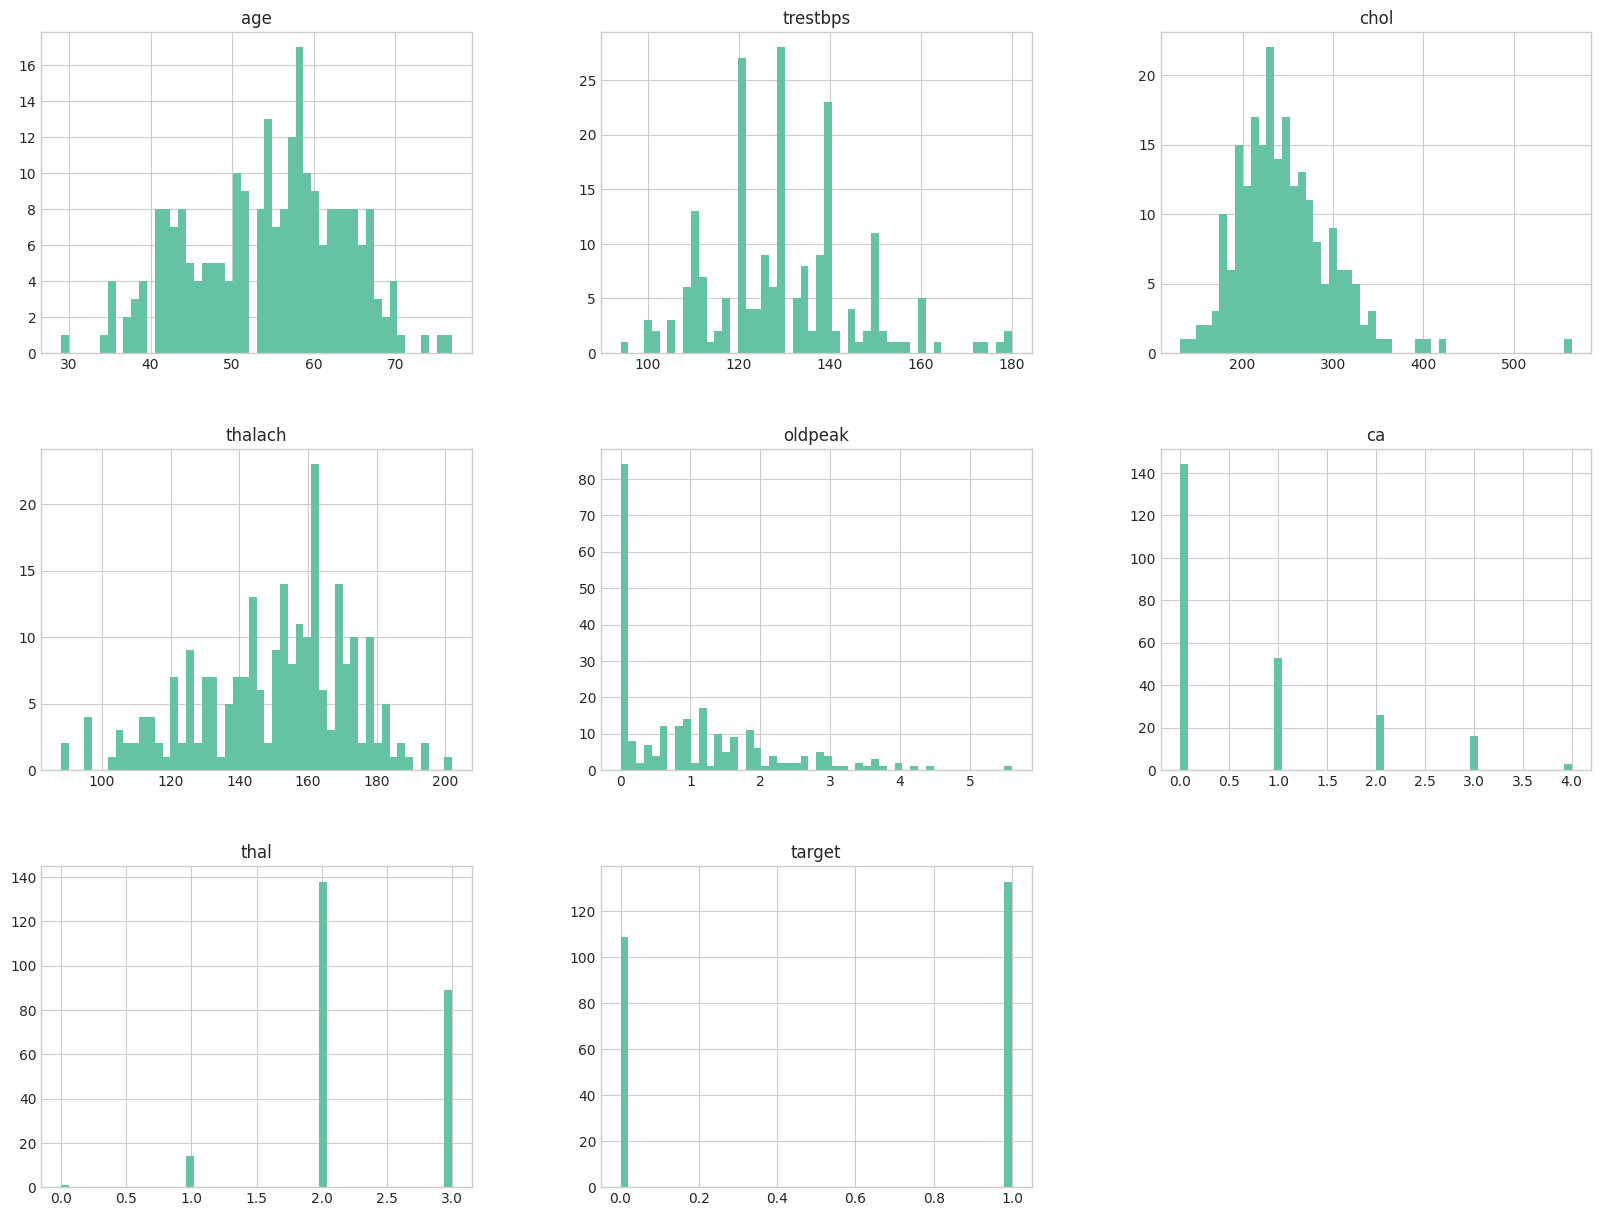

In [0]:
# TODO: Genera histogramas del conjunto de entrenamiento.
# train_set.hist(bins=50, figsize=(20, 15))
# plt.show()

# TODO: Identifica características con escalas o distribuciones muy diferentes.

train_set.hist(bins=50, figsize=(20, 15))
plt.show()

Se identifican variables en rangos elevados como chol, thalach y trestbps. Esto puede llevarnos a la conclusión de que se puede hacer un escalado de valores para entrenar el modelo.

### 📏 Observación Importante: Escalas Diferentes

**TODO: [Completa aquí] ¿Por qué es un problema que las características tengan escalas diferentes?**

Revisa columnas como `age`, `trestbps`, `chol`, `thalach` y `oldpeak`.

**TODO: [Completa aquí] ¿Qué transformación aplicarías para que las variables numéricas sean comparables?**

**TODO: [Completa aquí] ¿Por qué esto ayuda a algunos modelos de Machine Learning?**


## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [0]:
# TODO: Clasifica las columnas en categóricas y numéricas.
# cat_attr = [...]
# num_attr = [...]

# TODO: Crea un pipeline para variables numéricas.
# Pistas:
# - SimpleImputer para valores nulos
# - StandardScaler para estandarizar
# num_pipeline = Pipeline([
#     (...),
#     (...),
# ])

# TODO: Crea un ColumnTransformer que combine numéricas y categóricas.
# Pista: usa OneHotEncoder para variables categóricas.
# full_pipeline = ColumnTransformer([
#     (...),
#     (...),
# ])

# TODO: Explica por qué usamos One-Hot Encoding para categóricas.

num_attr = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_attr = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attr),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attr)
])


El One-Hot Encoding convierte las variables categóricas en columnas binarias para que pueda utilizarlas como variables en el modelo (no puede entrenarse con valores no numéricos).

## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [0]:
# TODO: Separa características (X) y target (y) del conjunto de entrenamiento.
# x_train = ...
# y_train = ...

# TODO: Comprueba las dimensiones resultantes.

X_train = train_set.drop('target', axis=1)
y_train = train_set['target']

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")


Dimensiones de X_train: (242, 13)
Dimensiones de y_train: (242,)


In [0]:
# TODO: Aplica el pipeline al conjunto de entrenamiento.
# x_train_pr = full_pipeline.fit_transform(x_train)

# TODO: Explica la diferencia entre fit_transform y transform.
# TODO: Comprueba cómo cambia el número de columnas.

X_train_prepared = full_pipeline.fit_transform(X_train)

print(f"Dimensiones de X_train antes de transformar: {X_train.shape}")
print(f"Dimensiones de X_train después de transformar: {X_train_prepared.shape}")


Dimensiones de X_train antes de transformar: (242, 13)
Dimensiones de X_train después de transformar: (242, 30)


Usamos fit_transform en entrenamiento para calcular parámetros (media, desviación) y transformar, mientras que transform solo aplica esos parámetros aprendidos en datos de prueba.

## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

**TODO: [Completa aquí] ¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?**

Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [0]:
# TODO: Activa autolog de MLflow.
# mlflow.sklearn.autolog()

# TODO: Inicia un run para el modelo baseline SGD.
# with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
#     TODO: Crea SGDClassifier.
#     sgd_clf = SGDClassifier(...)
#
#     TODO: Evalúa con cross_val_score.
#     scores = cross_val_score(...)
#
#     TODO: Registra métricas de validación cruzada en MLflow.
#     mlflow.log_metric(...)
#
#     TODO: Interpreta el resultado obtenido.

mlflow.sklearn.autolog()

with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
    sgd_clf = SGDClassifier(random_state=42)
    scores = cross_val_score(sgd_clf, X_train_prepared, y_train, cv=5, scoring="accuracy")
    mlflow.log_metric("cv_accuracy_mean", scores.mean())


2026/10/02 17:57:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 17:57:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 17:57:24 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 17:57:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3354352112167079/models/m-fc14e88e8802477ab7b7736b1f7908e0?o=7474659306803469
2026/10/02 17:57:30 WARNING mlflow.t

### 📊 Evaluación del Modelo SGD

In [0]:
# TODO: Obtén predicciones con validación cruzada.
# preds = cross_val_predict(...)

# TODO: Explica por qué cross_val_predict es útil para construir métricas y matriz de confusión.

preds = cross_val_predict(sgd_clf, X_train_prepared, y_train, cv=5)

2026/10/02 18:00:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 18:00:45 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '7154e88e9a944c8ebd914b04b0d543b6', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/02 18:00:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 18:00:45 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 18:00:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a Co

cross_val_predict permite evaluar las predicciones en muestras que el modelo no vio durante el entrenamiento, garantizando una matriz de confusión sin sesgo por sobreajuste.

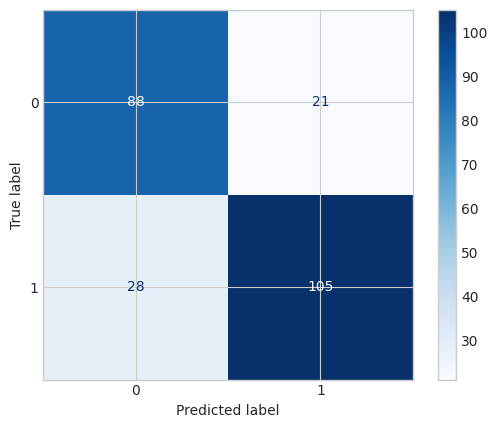

In [0]:
# TODO: Calcula y visualiza la matriz de confusión del modelo SGD.
# cm = confusion_matrix(...)
# disp = ConfusionMatrixDisplay(...)
# disp.plot(...)
# plt.show()

# TODO: Interpreta TN, FP, FN y TP.
# TODO: ¿Qué tipo de error es más grave en medicina?

cm = confusion_matrix(y_train, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()


TN y TP son aciertos (sanos y enfermos bien identificados), FP son falsas alarmas y FN son pacientes enfermos clasificados por error como sanos.
En medicina el error más grave es el Falso Negativo (FN), ya que implica no diagnosticar a un paciente enfermo y dejarlo sin tratamiento vital. En este caso al tratarse de infartos, tiene un riesgo muy elevado.

In [0]:
# TODO: Calcula métricas del modelo SGD.
# precision = precision_score(...)
# recall = recall_score(...)
# f1 = f1_score(...)
# roc_auc = roc_auc_score(...)

# TODO: Imprime e interpreta las métricas.

precision = precision_score(y_train, preds)
recall = recall_score(y_train, preds)
f1 = f1_score(y_train, preds)
roc_auc = roc_auc_score(y_train, preds)

print(f"Precisión: {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Precisión: 0.8333
Recall (Sensibilidad): 0.7895
F1-Score: 0.8108
ROC-AUC: 0.7984


El modelo alcanza una precisión del 83.3% y un F1-score de 0.81, pero un Recall del 78.9% indica que aún se pasa por alto un 21% de los casos positivos de enfermedad. En este caso, por la importancia de los falsos negativos nos pide llegar a un Recall probablemente más elevado.

### 🌲 Modelo 2: Random Forest Classifier

**TODO: [Completa aquí] ¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?**

Ahora probemos un modelo más potente y comparemos resultados.

In [0]:
# TODO: Entrena y evalúa un Random Forest en un nuevo run de MLflow.
# with mlflow.start_run(run_name="Random Forest Classifier") as run:
#     rf_clf = RandomForestClassifier(...)
#     rf_scores = cross_val_score(...)
#     rf_preds = cross_val_predict(...)
#     mlflow.log_metric(...)
#
# TODO: Explica qué hiperparámetros podrías ajustar y por qué comparas contra SGD.

with mlflow.start_run(run_name="Random Forest Classifier") as run:
    
    rf_clf = RandomForestClassifier(random_state=42)
    rf_scores = cross_val_score(rf_clf, X_train_prepared, y_train, cv=5, scoring="accuracy")
    rf_preds = cross_val_predict(rf_clf, X_train_prepared, y_train, cv=5)
    
    mlflow.log_metric("cv_accuracy_mean", rf_scores.mean())


2026/10/02 18:07:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 18:07:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 18:07:52 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 18:07:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3354352112167079/models/m-13ad6e8665b348eba5ccc033d652a593?o=7474659306803469
2026/10/02 18:07:57 WARNING mlflow.t

Ajustaríamos hiperparámetros como n_estimators o max_depth, y comparamos con SGD para evaluar si un modelo no lineal mejora las métricas que hemos calculado en el baseline.

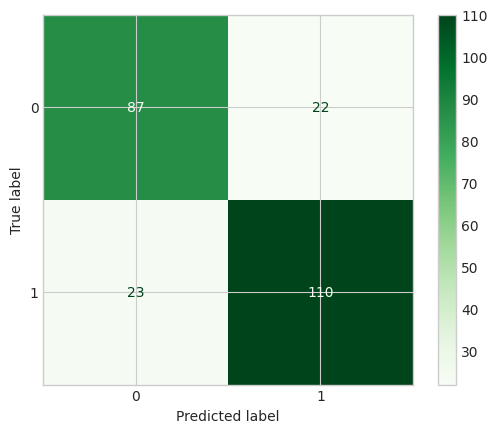

In [0]:
# TODO: Calcula y visualiza la matriz de confusión de Random Forest.
# cm_rf = confusion_matrix(...)
# disp_rf = ConfusionMatrixDisplay(...)
# disp_rf.plot(...)
# plt.show()

# TODO: Compara los errores con los del modelo SGD.

cm_rf = confusion_matrix(y_train, rf_preds)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Greens')
plt.show()

Random Forest reduce los falsos negativos de 28 a 23 y aumenta los verdaderos positivos de 105 a 110 respecto a SGD, mejorando la detección de pacientes enfermos y priorizando la reducción de los falsos negativos que son más graves en este contexto.

In [0]:
# TODO: Calcula métricas de Random Forest.
# rf_precision = precision_score(...)
# rf_recall = recall_score(...)
# rf_f1 = f1_score(...)
# rf_roc_auc = roc_auc_score(...)

# TODO: Crea una tabla comparativa SGD vs Random Forest.
# TODO: Decide qué modelo funciona mejor y justifica tu respuesta.

rf_precision = precision_score(y_train, rf_preds)
rf_recall = recall_score(y_train, rf_preds)
rf_f1 = f1_score(y_train, rf_preds)
rf_roc_auc = roc_auc_score(y_train, rf_preds)

comparison_df = pd.DataFrame({
    'Métrica': ['Precisión', 'Recall', 'F1-Score', 'ROC-AUC'],
    'SGD Classifier': [precision, recall, f1, roc_auc],
    'Random Forest': [rf_precision, rf_recall, rf_f1, rf_roc_auc]
})
print(comparison_df)

     Métrica  SGD Classifier  Random Forest
0  Precisión        0.833333       0.833333
1     Recall        0.789474       0.827068
2   F1-Score        0.810811       0.830189
3    ROC-AUC        0.798407       0.812616


Random Forest es superior porque ofrece un Recall y F1-Score más altos, capturando mejor los patrones complejos y reduciendo el riesgo en falsos negativos.

## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [0]:
# TODO: Entrena el modelo final usando todo el conjunto de entrenamiento procesado.
# forest_clf = RandomForestClassifier(...)
# forest_clf.fit(...)

# TODO: Explica por qué ahora entrenamos con todos los datos de train.

forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(X_train_prepared, y_train)


2026/10/02 18:12:41 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 18:12:41 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'cc3d38804ead4c828f8d6303f36ee518', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/02 18:12:41 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 18:12:41 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 18:12:42 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a Co

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Entrenamos con el 100% de los datos de train para aprovechar al máximo la información disponible antes de evaluar el rendimiento final.

In [0]:
# TODO: Separa características y target del conjunto de prueba.
# x_test = ...
# y_test = ...

# TODO: Comprueba dimensiones.

X_test = test_set.drop('target', axis=1)
y_test = test_set['target']

print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_test: (61, 13)
Dimensiones de y_test: (61,)


In [0]:
# TODO: Transforma el conjunto de prueba y genera predicciones.
# x_test_pr = full_pipeline.transform(x_test)
# final_preds = forest_clf.predict(x_test_pr)

# TODO: Explica por qué usamos transform() y no fit_transform() en test.

X_test_prepared = full_pipeline.transform(X_test)
final_preds = forest_clf.predict(X_test_prepared)

2026/10/02 18:13:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


Accuracy Final: 0.8525
Precisión Final: 0.8710
Recall Final: 0.8438
F1-Score Final: 0.8571
ROC-AUC Final: 0.8529


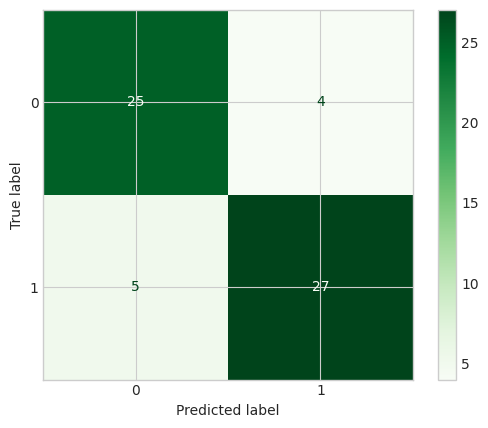


Informe de Clasificación Final:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [0]:
# TODO: Evalúa resultados finales en el conjunto de prueba.
# final_precision = precision_score(...)
# final_recall = recall_score(...)
# final_f1 = f1_score(...)
# final_roc_auc = roc_auc_score(...)
# final_accuracy = accuracy_score(...)

# TODO: Visualiza la matriz de confusión final.
# TODO: Genera classification_report.
# TODO: Interpreta si el modelo generaliza bien.

final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_preds)
final_accuracy = accuracy_score(y_test, final_preds)

print(f"Accuracy Final: {final_accuracy:.4f}")
print(f"Precisión Final: {final_precision:.4f}")
print(f"Recall Final: {final_recall:.4f}")
print(f"F1-Score Final: {final_f1:.4f}")
print(f"ROC-AUC Final: {final_roc_auc:.4f}")

cm_final = confusion_matrix(y_test, final_preds)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final)
disp_final.plot(cmap='Greens')
plt.show()

print("\nInforme de Clasificación Final:")
print(classification_report(y_test, final_preds))

El modelo generaliza mejor que las versiones anteriores en datos no vistos, alcanzando un 85.25% de exactitud y un 84.38% de Recall con solo 5 falsos negativos en prueba que se acerca más al objetivo que estamos intentando alcanzar.

## 🎉 Reflexión Final del Proyecto

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración de datos médicos reales
2. [ ] Pipeline de preprocesamiento
3. [ ] Entrenamiento y comparación de modelos
4. [ ] Evaluación con métricas de clasificación
5. [ ] Validación cruzada
6. [ ] Registro de experimentos en MLflow
7. [ ] Interpretación de resultados con matrices de confusión

### 📊 Conclusiones Clave

**TODO: Basándote en tus resultados, escribe tus conclusiones:**

1. **¿Qué modelo funcionó mejor?**
   - [Tu respuesta aquí]

2. **¿Por qué crees que funcionó mejor?**
   - [Tu respuesta aquí]

3. **¿El modelo es suficientemente bueno para uso médico?**
   - [Tu respuesta aquí]

4. **¿Qué métrica es más importante en este caso?**
   - [Tu respuesta aquí]

5. **¿Qué mejorarías del modelo?**
   - [Tu respuesta aquí]

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina e IA

**TODO: Reflexiona sobre:**

1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   - [Tu respuesta aquí]

2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - [Tu respuesta aquí]

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - [Tu respuesta aquí]

---

### 🚀 Desafíos Adicionales

1. **Optimización de Hiperparámetros** con `GridSearchCV`.
2. **Prueba Otros Modelos** como Gradient Boosting, SVM o Logistic Regression.
3. **Feature Engineering** para crear o seleccionar características.
4. **Análisis de Errores** para entender pacientes mal clasificados.
5. **Curva ROC** para comparar thresholds y AUC.


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del proyecto.

# ========================================
# TODO: DESAFÍO 1 - Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# param_grid = {...}
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

# ========================================
# TODO: DESAFÍO 2 - Curva ROC
# ========================================
# from sklearn.metrics import roc_curve, auc
# y_proba = ...
# fpr, tpr, thresholds = roc_curve(...)
# TODO: visualiza la curva ROC.

# ========================================
# TODO: DESAFÍO 3 - Importancia de características
# ========================================
# feature_names = ...
# feature_importance = ...
# TODO: identifica e interpreta las características más importantes.

# ========================================
# TODO: DESAFÍO 4 - Comparar más modelos
# ========================================
# modelos = {...}
# resultados = []
# for nombre, modelo in modelos.items():
#     # Entrena, evalúa y registra cada modelo en MLflow
#     pass
